In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [84]:
# Relative path from notebooks/data_load.ipynb to data/raw/FW_Veg_Rem_Combined.csv
df = pd.read_csv('../data/raw/FW_Veg_Rem_Combined.csv')

# Check it loaded correctly
df.head()


,Unnamed: 0.1,Unnamed: 0,fire_name,fire_size,fire_size_class,stat_cause_descr,latitude,longitude,state,disc_clean_date,...,Wind_cont,Hum_pre_30,Hum_pre_15,Hum_pre_7,Hum_cont,Prec_pre_30,Prec_pre_15,Prec_pre_7,Prec_cont,remoteness
0,0,0,NaN,10.0,C,Missing/Undefined,18.105072,-66.753044,PR,2/11/2007,...,3.250413,78.216590,76.793750,76.381579,78.724370,0.0,0.0,0.0,0.0,0.017923
1,1,1,NaN,3.0,B,Arson,35.038330,-87.610000,TN,12/11/2006,...,2.122320,70.840000,65.858911,55.505882,81.682678,59.8,8.4,0.0,86.8,0.184355
2,2,2,NaN,60.0,C,Arson,34.947800,-88.722500,MS,2/29/2004,...,3.369050,75.531629,75.868613,76.812834,65.063800,168.8,42.2,18.1,124.5,0.194544
3,3,3,WNA 1,1.0,B,Debris Burning,39.641400,-119.308300,NV,6/6/2005,...,0.000000,44.778429,37.140811,35.353846,0.000000,10.4,7.2,0.0,0.0,0.487447
4,4,4,NaN,2.0,B,Miscellaneous,30.700600,-90.591400,LA,9/22/1999,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,-1.0,-1.0,-1.0,0.214633


In [85]:
vars_to_keep = [
    "fire_size",
    "fire_size_class",
    "latitude",
    "longitude",
    "discovery_month",
    "disc_pre_year",
    "Vegetation",
    "Temp_pre_30",
    "Temp_pre_15",
    "Temp_pre_7",
    "Wind_pre_30",
    "Wind_pre_15",
    "Wind_pre_7",
    "Hum_pre_30",
    "Hum_pre_15",
    "Hum_pre_7",
    "Prec_pre_30",
    "Prec_pre_15",
    "Prec_pre_7",
    "remoteness"
    ]
# Select only the columns we want to keep
df = df[vars_to_keep]
# Check the columns we kept
df.head()

,fire_size,fire_size_class,latitude,longitude,discovery_month,disc_pre_year,Vegetation,Temp_pre_30,Temp_pre_15,Temp_pre_7,Wind_pre_30,Wind_pre_15,Wind_pre_7,Hum_pre_30,Hum_pre_15,Hum_pre_7,Prec_pre_30,Prec_pre_15,Prec_pre_7,remoteness
0,10.0,C,18.105072,-66.753044,Feb,2007,12,24.480974,24.716923,24.902597,4.341807,3.492857,3.262092,78.216590,76.793750,76.381579,0.0,0.0,0.0,0.017923
1,3.0,B,35.038330,-87.610000,Dec,2006,15,7.553433,7.010000,0.343529,2.709764,2.881707,1.976471,70.840000,65.858911,55.505882,59.8,8.4,0.0,0.184355
2,60.0,C,34.947800,-88.722500,Feb,2004,16,4.971930,5.782766,5.558750,3.364499,2.923830,2.695833,75.531629,75.868613,76.812834,168.8,42.2,18.1,0.194544
3,1.0,B,39.641400,-119.308300,Jun,2005,0,16.275967,18.996181,18.142564,4.054982,3.398329,3.671282,44.778429,37.140811,35.353846,10.4,7.2,0.0,0.487447
4,2.0,B,30.700600,-90.591400,Sep,1999,12,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,-1.0,-1.0,0.214633


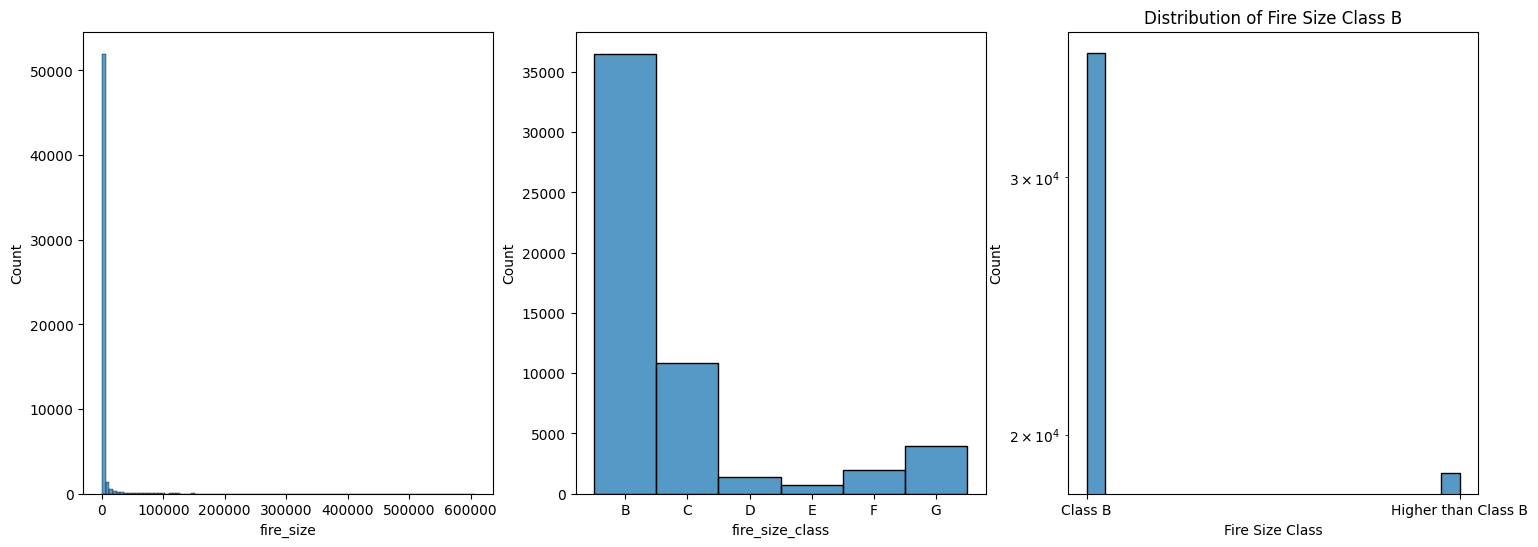

In [86]:
# Compare distribution of fire size classes with distribution of fire sizes
# order fire size classes variable alphabetically
df.fire_size_class = pd.Categorical(df.fire_size_class, ordered=True)

def plot_fire_dist_triple(df):
    # Three plots next to each other
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Plot the distribution of fire sizes
    sns.histplot(df.fire_size, bins=100, ax=axes[0])
    plt.yscale('log')
    plt.xlabel('Fire Size (ha)')
    plt.ylabel('Count')
    plt.title('Distribution of Fire Sizes')

    # Plot the distribution of fire size classes
    sns.histplot(df.fire_size_class, bins=100, ax=axes[1])
    plt.xlabel('Fire Size Class')
    plt.ylabel('Count')
    plt.title('Distribution of Fire Size Classes')

    # Plot the distribution of fire size classes B and all others taken together
    # Create binary fire_size_class variable
    df['catastrophic'] = df.fire_size_class.apply(lambda x: 0 if x == 'B' else 1)

    # Show only 0 and 1 on the x-axis and switch 0 and 1 so 1 is on the left
    sns.histplot(df.catastrophic, ax=axes[2])
    plt.xticks([0, 1], ['Class B', 'Higher than Class B'])
    plt.xlabel('Fire Size Class')
    plt.ylabel('Count')
    plt.title('Distribution of Fire Size Class B')
    plt.show()
    
plot_fire_dist_triple(df)


<Axes: xlabel='catastrophic'>

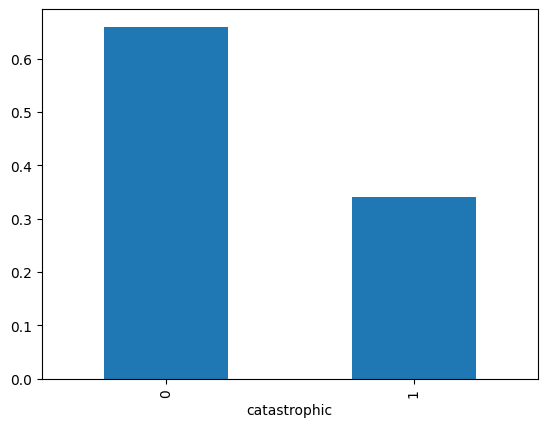

In [87]:
df.catastrophic.value_counts(normalize=True).plot(kind='bar')

In [88]:
# Check for missing values
df.isnull().sum()

fire_size          0
fire_size_class    0
latitude           0
longitude          0
discovery_month    0
disc_pre_year      0
Vegetation         0
Temp_pre_30        0
Temp_pre_15        0
Temp_pre_7         0
Wind_pre_30        0
Wind_pre_15        0
Wind_pre_7         0
Hum_pre_30         0
Hum_pre_15         0
Hum_pre_7          0
Prec_pre_30        0
Prec_pre_15        0
Prec_pre_7         0
remoteness         0
catastrophic       0
dtype: int64

In [89]:
df.describe()



,fire_size,latitude,longitude,disc_pre_year,Vegetation,Temp_pre_30,Temp_pre_15,Temp_pre_7,Wind_pre_30,Wind_pre_15,Wind_pre_7,Hum_pre_30,Hum_pre_15,Hum_pre_7,Prec_pre_30,Prec_pre_15,Prec_pre_7,remoteness,catastrophic
count,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000
mean,2104.645161,36.172866,-94.757971,2003.765474,11.066068,10.688533,10.800765,10.907171,1.926108,1.844133,1.791331,40.781796,38.453935,37.001865,26.277046,11.654253,4.689920,0.236799,0.340365
std,14777.005364,6.724348,15.878194,6.584889,5.595719,10.467579,10.633803,10.807985,2.106165,2.122697,2.139708,31.086856,31.042541,30.827885,112.050198,56.920510,31.205327,0.144865,0.473836
min,0.510000,17.956533,-165.936000,1991.000000,0.000000,-49.210526,-37.000000,-20.846104,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,0.000000
25%,1.200000,32.265960,-102.541513,1999.000000,9.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.137800,0.000000
50%,4.000000,34.600000,-91.212359,2005.000000,12.000000,9.945559,10.122047,10.237860,2.422880,2.295954,2.175431,55.657480,51.753846,48.230769,0.000000,0.000000,0.000000,0.202114,0.000000
75%,20.000000,38.975235,-82.847500,2009.000000,15.000000,20.015591,20.259329,20.502848,3.469751,3.435482,3.392260,67.384352,65.911469,64.645296,18.900000,3.600000,0.000000,0.284782,1.000000
max,606945.000000,69.849500,-65.285833,2015.000000,16.000000,46.600000,51.567797,55.000000,29.800000,29.800000,25.700000,96.000000,94.000000,96.000000,13560.800000,2527.000000,1638.000000,1.000000,1.000000


We see that while we do not have any NaN or explicitly missing values there are illogical values indicating missing values or entry errors. Obviously there cannot be negative wind speeds, humidity or precipitation.

In [90]:
df_2 = df[df["Wind_pre_30"] >= 0]
df_2.reset_index(drop=True, inplace=True)
df_2.describe()

,fire_size,latitude,longitude,disc_pre_year,Vegetation,Temp_pre_30,Temp_pre_15,Temp_pre_7,Wind_pre_30,Wind_pre_15,Wind_pre_7,Hum_pre_30,Hum_pre_15,Hum_pre_7,Prec_pre_30,Prec_pre_15,Prec_pre_7,remoteness,catastrophic
count,41132.000000,41132.000000,41132.000000,41132.000000,41132.000000,41132.000000,41132.000000,41132.000000,41132.000000,41132.000000,41132.000000,41132.000000,41132.000000,41132.000000,41132.000000,41132.000000,41132.000000,41132.000000,41132.000000
mean,2268.659983,36.459499,-95.776712,2004.740202,11.054362,14.733711,14.884784,15.028015,2.938778,2.828433,2.757357,55.241678,52.108189,50.153585,35.717111,16.033648,6.659093,0.244195,0.351065
std,15178.186225,6.807528,15.958848,6.389088,5.580364,9.156641,9.345450,9.549321,1.407970,1.515536,1.591563,22.081281,23.915985,24.627087,128.661818,65.472557,35.995864,0.146091,0.477309
min,0.510000,17.958364,-165.116700,1991.000000,0.000000,-49.210526,-37.000000,-20.846104,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.200000,32.353824,-104.435674,2000.000000,9.000000,7.819388,7.791912,7.722732,2.160604,1.998421,1.835798,48.856802,43.775779,40.102738,0.000000,0.000000,0.000000,0.140916,0.000000
50%,4.000000,34.688619,-93.024989,2006.000000,12.000000,14.608275,14.963175,15.374281,2.955700,2.878302,2.801571,62.857816,60.591284,58.399387,0.500000,0.000000,0.000000,0.208428,0.000000
75%,20.000000,39.729506,-83.699150,2010.000000,15.000000,22.663678,22.902253,23.163016,3.796231,3.769035,3.748132,69.667930,68.575084,67.716424,37.300000,12.000000,1.500000,0.293291,1.000000
max,538049.000000,69.047200,-65.417709,2015.000000,16.000000,46.600000,51.567797,55.000000,29.800000,29.800000,25.700000,96.000000,94.000000,96.000000,13560.800000,2527.000000,1638.000000,1.000000,1.000000


This already seemed to remove all the negatively coded values. The precipitation values appear to be recorded cumulatively as the maximum value is far above the worldwide record for daily precipitation and for all observations the precipitation values decrease or stay constant from pre_30 to pre_7.

/var/folders/z7/0999sht128s_z3s9njjhlzph0000gn/T/ipykernel_67261/3237242901.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['catastrophic'] = df.fire_size_class.apply(lambda x: 0 if x == 'B' else 1)


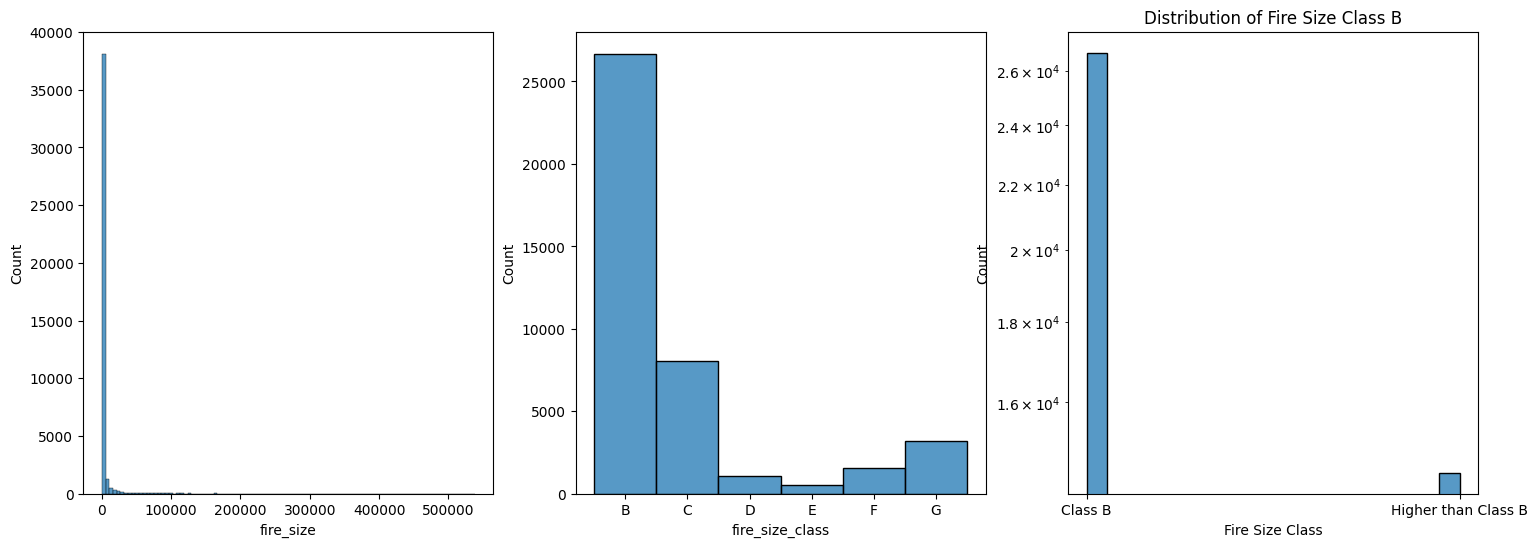

catastrophic
0    26692
1    14440
Name: count, dtype: int64

In [91]:
plot_fire_dist_triple(df_2)
df_2.catastrophic.value_counts()

When looking at the weather data more closely we found many more cases of likely missing values that needed to be dealt with. In many rows temperatures, winds, and humidities included exact zero values. 
1. We drop each row where either the temperature triplet, the wind triplet or the humidity triplet is three zeros. 
2. If only one value of the triplet is positive, the same value is used for the other two values. 
3. If we have e.g. two positive humidity values then the third one is interpolated by trend. 
    
    3.1 If the middle one is missing we take the weighted mean. Weighted because the 15 day value is not directly in the middle of 30 and 7 days. 

    3.2 If only the first or third value is missing we build a trend from the remaining two and add/substract that, taking the number of days into account. We avoid negative interpolations for humidity and wind using the max function. For humidity we also need a maximum cap at 100.



In [ ]:
temps = ["Temp_pre_30", "Temp_pre_15", "Temp_pre_7"]
winds = ["Wind_pre_30", "Wind_pre_15", "Wind_pre_7"]
hums = ["Hum_pre_30", "Hum_pre_15", "Hum_pre_7"]

weather_list = [temps, winds, hums]

# First we justify our interpolation style:
# Look at each non-zero weather triplet, and check if a continous trend is present in the existing data
# For each row capture the index of the maximum value in each triplet
for o in weather_list:
    max_indices = df_2[o].idxmax(axis=1)
    print(max_indices.value_counts())

Temp_pre_7     18422
Temp_pre_30    14342
Temp_pre_15     8368
Name: count, dtype: int64
Wind_pre_30    18655
Wind_pre_7     13472
Wind_pre_15     9005
Name: count, dtype: int64
Hum_pre_30    23033
Hum_pre_7     10090
Hum_pre_15     8009
Name: count, dtype: int64


In [ ]:
def replace_missing_grouped_mean(df, group_list):
    df_copy = df.copy()
    #iterate over  rows
    for i, row in df_copy.iterrows():
        for o in weather_list:
            values = [row[o[0]], row[o[1]], row[o[2]]]
            id_zeros = [x == 0 for x in values]
            # If all three values are zero drop row.
            if  sum(id_zeros) == 3:
                #drop row from df with current index
                df_copy.drop(i, inplace=True)
                #continue to next row (here use break because we are in a nested loop)
                break
            # If none are zero continue to next triplet.
            elif sum(id_zeros) == 0:
                continue
            # If only the middle value is zero replace with weighted mean.
            elif id_zeros[1] and np.sum(id_zeros) == 1:
                df_copy.at[i, o[1]] = values[0] * 1/3 + values[2] * 2/3
            # If two values are missing replace missing values with single positive value.
            elif id_zeros[1] or np.logical_and(id_zeros[0], id_zeros[2]):
                nonzero_val = np.sum(values)
               
                df_copy.at[i, o[0]] = nonzero_val
                df_copy.at[i, o[1]] = nonzero_val
                df_copy.at[i, o[2]] = nonzero_val 
            else:
                # if last value (pre_7) is 0, build trend from first two
                if id_zeros[2]:
                    trend = values[1]-values[0]
                    # since trend is 15 days here we need to halve to get from 15 to 7
                    # also we need to avoid negative values for humidity and wind
                    if o == temps:
                        df_copy.at[i,o[2]] = values[1] + 0.5 * trend
                    else:
                        # We can set the 100 cap also for winds as no values get close to 100 anyway.
                        df_copy.at[i,o[2]] = min((max((values[1] + 0.5 * trend,0)),100))
                # if only first value (pre_30) is zero build trend backwards
                else:
                    trend = values[1]-values[2]
                    # since trend is 7 days here we need to double to get from 15 to 30
                    if 0 == temps:
                        df_copy.at[i,o[0]] = values[1] + 2 * trend
                    else:
                        # We can set the 100 cap also for winds as no values get close to 100 anyway.
                        df_copy.at[i,o[0]] = min((max((values[1] + 2 * trend,0)),100))
            
    return df_copy
    
df_3 = replace_missing_grouped_mean(df_2, weather_list)

In [82]:
df_3.describe()

,fire_size,latitude,longitude,disc_pre_year,Vegetation,Temp_pre_30,Temp_pre_15,Temp_pre_7,Wind_pre_30,Wind_pre_15,Wind_pre_7,Hum_pre_30,Hum_pre_15,Hum_pre_7,Prec_pre_30,Prec_pre_15,Prec_pre_7,remoteness,catastrophic
count,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000
mean,2211.284929,36.475461,-95.643236,2004.802435,11.072646,15.751560,16.252676,16.611517,3.171764,3.160079,3.136735,60.973810,60.040488,58.949642,39.482359,17.723995,7.361304,0.243298,0.346216
std,14890.174705,6.813169,15.877186,6.393584,5.556529,8.534825,8.417871,8.474401,1.177843,1.227829,1.313413,13.714828,14.182339,14.896525,134.725873,68.620599,37.778079,0.144646,0.475769
min,0.510000,17.958364,-165.116700,1991.000000,0.000000,-16.078723,-37.000000,-48.200000,0.024922,0.017250,0.000000,5.625000,5.625000,5.625000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.100000,32.377439,-103.445108,2000.000000,9.000000,9.127583,9.715080,10.037742,2.350902,2.299691,2.221819,55.237437,53.461904,50.968015,0.000000,0.000000,0.000000,0.140661,0.000000
50%,4.000000,34.699420,-93.185815,2006.000000,12.000000,15.555082,16.070776,16.600000,3.072371,3.053857,3.010513,64.213802,63.044628,61.650099,3.400000,0.000000,0.000000,0.210863,0.000000
75%,20.000000,39.783547,-83.550410,2010.000000,15.000000,23.115392,23.434649,23.793842,3.868383,3.877827,3.891667,70.334410,69.892706,69.469600,43.600000,15.125000,2.300000,0.291913,1.000000
max,538049.000000,69.047200,-65.417709,2015.000000,16.000000,41.677820,51.567797,55.000000,29.800000,29.800000,29.800000,96.000000,96.000000,114.794807,13560.800000,2527.000000,1638.000000,1.000000,1.000000


In [70]:
# load df_3 as a csv file into the data/processed folder
df_3.to_csv('../data/processed/FW_Veg_Rem_Combined_cleaned.csv', index=False)